<H1>TP 1 - Analyse et ingénierie des données</H1>

Le TP porte sur l'analyse et l'ingénierie des données à partir du jeu de données
`Titanic`, un jeu classique en apprentissage automatique. Il rassemble diverses
informations sur les passagers du navire (âge, classe, tarif du billet, sexe, port d'embarquement, etc.) ainsi que leur survie.    

Ce TP permet de parcourir les étapes essentielles d'un premier traitement de données : exploration, visualisation, gestion des valeurs manquantes et transformation des variables. L'objectif est d'obtenir une version propre du jeu de données qui pourra être utilisé pour faire de l'apprentissage.  

<p align="center">
  <img src="http://www.lirmm.fr/~poncelet/Ressources/titanic.png"
       width="400">
</p>

Source : https://fr.wikipedia.org/wiki/Titanic


# Environnement

Ce notebook peut fonctionner sur plusieurs environnement `Jupyter`. Il n'est pas nécessaire d'utiliser un environnement disposant de GPU.  

**Pour les utilisateurs de Colab :**

Pour pouvoir utiliser votre répertoire `Google Drive`, il est nécessaire de fournir une autorisation. Pour cela il suffit de décommenter, si nécessaire, et d'exécuter la cellule suivante.

In [3]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


Décommenter, si necessaire, les lignes et corriger la ligne `my_local_drive` pour mettre le chemin vers un répertoire spécifique de votre répertoire Google Drive.

In [4]:
import sys
import os

my_local_drive='/content/gdrive/MyDrive/Colab Notebooks/tp1_ml'

if not os.path.exists(my_local_drive):
    os.makedirs(my_local_drive)
    print(f"Dossier '{my_local_drive}' créé avec succès !")

sys.path.append(my_local_drive)

Il faut décommenter, si nécessaire, la ligne suivante pour se positionner dans le répertoire associé.

In [5]:
%cd {my_local_drive}

/content/gdrive/MyDrive/Colab Notebooks/tp1_ml


# Installation

Les librairies utiles pour le TP sont toutes déclarées au début pour ne pas surcharger les affichages.

In [6]:
# Importation des différentes librairies utiles pour le notebook
# Gestion des warnings
import warnings                   # Masquer certains avertissements
warnings.filterwarnings("ignore", category=FutureWarning)

# Manipulation de données
import pandas as pd               # Tables et opérations sur les données

# Visualisation
import seaborn as sns             # Visualisation statistique
import matplotlib.pyplot as plt   # Graphiques de base

# Prétraitement (Scikit-learn)
from sklearn.preprocessing import LabelEncoder  # Encodage de variables
from sklearn.preprocessing import StandardScaler # Normalisation

# Système
import sys                        # Informations sur l'environnement

# Analyse des données

Avant d'aller plus loin, il est important de prendre le temps de regarder les
données. Une bonne compréhension du contenu, des types de variables et de leur
structure aide à éviter des erreurs par la suite et oriente les choix de nettoyage et de transformation.

Nous allons commencer par charger le fichier `Titanic` dans un DataFrame pandas.
Ce format est pratique pour explorer rapidement un jeu de données : aperçu des
lignes, sélection de colonnes, statistiques simples, repérage des valeurs
manquantes, etc.

Vous pourrez retrouver les commandes essentielles pour bien manipuler pandas ici : [pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf).


Dans un premier temps, télécharger le fichier en exécutant la cellule suivante :

In [ ]:
%%capture
!wget https://www.lirmm.fr/~poncelet/Ressources/titanic.csv

Le fichier `titanic.csv` doit maintenant être disponible dans votre répertoire
Google Drive défini auparavant. Nous pouvons ensuite le charger dans un
DataFrame pandas à l'aide de la commande suivante :

In [7]:
#attention le séparateur est une tabulation
df=pd.read_csv('titanic.csv',
               sep='\t')

L'objectif est d'utiliser quelques commandes de base de pandas pour obtenir une
première vue d'ensemble du jeu de données. Cela permet de vérifier rapidement
sa structure, repérer d'éventuelles incohérences et se faire une idée des valeurs
présentes dans chaque colonne.

> **À FAIRE :**  
> - Afficher la taille du DataFrame.  
> - Afficher les six premières lignes.  
> - Afficher les trois dernières lignes.  
> - Afficher cinq lignes choisies au hasard.  

Ces opérations donnent un premier aperçu utile avant d'aller plus loin dans
l'analyse.


In [ ]:
# Afficher la taille
len(df)

156

In [ ]:
# Afficher les 6 premières ligne
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [ ]:
# Afficher les 3 dernières lignes
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
154,155,0,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,NaN,S
155,156,0,1,"Williams, Mr. Charles Duane",male,51.0,0,1,PC 17597,61.3792,NaN,C


In [ ]:
# Afficher 5 lignes au hasard
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
135,136,0,2,"Richard, Mr. Emile",male,23.0,0,0,SC/PARIS 2133,15.0458,NaN,C
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,NaN,S


> **À FAIRE :**  
> Afficher les informations concernant le cinquième passager du DataFrame.  

Pour rappel l'indexation commence à 0.

In [ ]:
# Afficher infos du 5ème passager
df.iloc[4]

,4
PassengerId,5
Survived,0
Pclass,3
Name,"Allen, Mr. William Henry"
Sex,male
Age,35.0
SibSp,0
Parch,0
Ticket,373450
Fare,8.05


> **À FAIRE :**  
> Afficher les informations concernant les passagers situés entre les lignes  
> 10 et 16 du DataFrame.  

In [ ]:
# Afficher infos du 10 au 16ème
df.iloc[10:16]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S


> **À FAIRE :**  
> Afficher les informations concernant le passager dont la valeur de  
> `PassengerId` est égale à 5.

In [ ]:
# Infos d'on le passengerId = 5
df.loc[df['PassengerId'] == 5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


> **À FAIRE :**  
> Afficher la liste des noms de colonnes du DataFrame.

In [ ]:
# Afficher la liste des noms
df.loc[:, ['Name']]

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
151,"Pears, Mrs. Thomas (Edith Wearne)"
152,"Meo, Mr. Alfonzo"
153,"van Billiard, Mr. Austin Blyler"
154,"Olsen, Mr. Ole Martin"


> **À FAIRE :**  
> Afficher les informations générales du DataFrame : nom des colonnes,  
> type de chaque colonne, nombre de valeurs non nulles et mémoire utilisée.

In [ ]:
# Infos général du dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  156 non-null    int64  
 1   Survived     156 non-null    int64  
 2   Pclass       156 non-null    int64  
 3   Name         156 non-null    object 
 4   Sex          156 non-null    object 
 5   Age          126 non-null    float64
 6   SibSp        156 non-null    int64  
 7   Parch        156 non-null    int64  
 8   Ticket       156 non-null    object 
 9   Fare         156 non-null    float64
 10  Cabin        31 non-null     object 
 11  Embarked     155 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 14.8+ KB


> **À FAIRE :**  
> Déterminer le type de la colonne `Name` dans le DataFrame.

In [ ]:
# Type de la colonne Name
df.dtypes['Name']

dtype('O')

Nous pourrions nous attendre à ce que la colonne `Name` soit de type `str`, mais
pandas utilise généralement le type `object` pour représenter des chaînes de
caractères. Ce type plus général permet de stocker des chaînes de longueurs
variables et, plus largement, n'importe quel objet Python. C'est pour cette
raison que les colonnes textuelles apparaissent en `object` plutôt qu'en `str`.

> **À FAIRE :**  
> Afficher les statistiques de base du DataFrame.


In [ ]:
# Statistiques du df
df.describe()

# Q1
# 34% des gens ont survecu

# Q2
# Y'avait tout type de gens

# Q3
# Car certaines valeurs n'ont pas été remplie, cela à pour conséquence de fausser le dataframe

# Q4
# Car son type n'est pas compatible avec describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,156.000000,156.000000,156.000000,126.000000,156.000000,156.000000,156.000000
mean,78.500000,0.346154,2.423077,28.141508,0.615385,0.397436,28.109587
std,45.177428,0.477275,0.795459,14.613880,1.056235,0.870146,39.401047
min,1.000000,0.000000,1.000000,0.830000,0.000000,0.000000,6.750000
25%,39.750000,0.000000,2.000000,19.000000,0.000000,0.000000,8.003150
50%,78.500000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,117.250000,1.000000,3.000000,35.000000,1.000000,0.000000,30.371850
max,156.000000,1.000000,3.000000,71.000000,5.000000,5.000000,263.000000


> **Questions :**
>
> 1. En observant les valeurs de la colonne `Survived`, comment interpréter la
>    moyenne obtenue (0.346) dans le contexte du jeu de données ?
> 2. Que peut-on déduire de la distribution de l'âge des passagers en observant
>    les valeurs minimum, maximum, médiane et l'écart-type ?
> 3. Pourquoi le nombre de valeurs pour `Age` (126) est-il inférieur à celui des
>    autres colonnes, et quelles conséquences cela peut-il avoir pour la suite  du TP ?
> 4. Pourquoi la colonne `Name` n'apparaît-elle pas dans le résultat ?


> **À FAIRE :**  
> Afficher un résumé descriptif de la colonne `Name` en utilisant la même
> commande que précédemment, mais appliquée uniquement à cette colonne.

In [ ]:
# Describe d'une seule colonne
df['Name'].describe()

# Q1
# Le nombre de ligne possédant une valeur

# Q2
# Personnes ne possèdent le même 'Name'

# Q3
# Le nom le plus souvent apparue (ici 1 choisie le premier dans l'ordre alphabétique)

# Q4
# Nombre d'apparition de la valeur top

,Name
count,156
unique,156
top,"Braund, Mr. Owen Harris"
freq,1


> **Questions :**
>
> 1. Que signifie la valeur affichée pour `count` dans ce résumé ?
> 2. Pourquoi `unique` vaut-il également 156 ?
> 3. La valeur `top` correspond à un nom particulier. Pourquoi ce nom apparaît-il
>    ici ?
> 4. Que peut-on conclure du fait que `freq` vaut 1 ?

> **À FAIRE :**  
> Déterminer le nombre de survivants dans le DataFrame.  
> Indication : il s'agit de compter combien de `PassengerId` ont une valeur de
> `Survived` égale à 1.

In [ ]:
# Nombre de passagers avec survived = 1
int(df['Survived'].sum())

54

> **À FAIRE :**  
> Comparer le nombre de survivants au nombre total de passagers et calculer la
> proportion de passagers ayant survécu.

In [ ]:
# Moyenne survie

print(f"Nombre passagers ayant survécu : {df['Survived'].sum()}")

print(f"Nombre passagers total : {df['Survived'].count()}")

print(f"Proportion : {float(df['Survived'].sum() / df['Survived'].count())}")

Nombre passagers ayant survécu : 54
Nombre passagers total : 156
Proportion : 0.34615384615384615


> **À FAIRE :**  
> Donner, pour chaque catégorie `male` et `female`, le nombre de personnes qui
> ont survécu et le nombre de personnes qui n'ont pas survécu.  
> Indication : utiliser un `groupby` sur les colonnes `Sex` et `Survived`.

In [ ]:
# Group by
df.groupby(by = ['Sex', 'Survived']).size()

Sex     Survived
female  0           16
        1           40
male    0           86
        1           14
dtype: int64

> **À FAIRE :**  
> Donner, pour chaque catégorie de classe (`Pclass`), le nombre de personnes qui
> ont survécu et le nombre de personnes qui n'ont pas survécu.


In [ ]:
# Group by
df.groupby(by = ['Pclass', 'Survived']).size()

Pclass  Survived
1       0           18
        1           12
2       0           16
        1           14
3       0           68
        1           28
dtype: int64

> **À FAIRE :**  
> Donner, pour chaque combinaison de classe (`Pclass`) et de sexe (`Sex`),  
> le nombre de personnes qui ont survécu et le nombre de personnes  
> qui n'ont pas survécu.


In [ ]:
# Group by
df.groupby(by = ['Sex', 'Pclass', 'Survived']).size()

Sex     Pclass  Survived
female  1       1            9
        2       0            1
                1           11
        3       0           15
                1           20
male    1       0           18
                1            3
        2       0           15
                1            3
        3       0           53
                1            8
dtype: int64

> **À FAIRE :**  
> Afficher la liste des femmes ayant survécu et dont l'âge est strictement
> supérieur à 30.

In [ ]:
# Liste femme survécu dont l'âge > 30
df.loc[(df['Age'] > 30) & (df['Survived'] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
74,75,1,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,NaN,S
85,86,1,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,3,0,3101278,15.8500,NaN,S


> **À FAIRE :**  
> Donner l'âge minimum, l'âge maximum et l'âge moyen des passagers ayant
> survécu.


In [ ]:
# Âge minimum, maximum et moyen des passagers ayant survécu

_df = df[df['Survived'] == 1]

print(f"Âge minimum : {_df['Age'].describe().min()}")

print(f"Âge maxmimum : {_df['Age'].describe().max()}")

print(f"Âge moyen : {_df['Age'].describe().mean()}")

Âge minimum : 0.83
Âge maxmimum : 58.0
Âge moyen : 26.934071280943343


Cette première analyse montre l'intérêt de parcourir les données à l'aide de
requêtes simples.

L'examinen des types, de voir qu'il manque des données, les répartitions
par groupes ou les caractéristiques des variables numériques permet d'obtenir
une première compréhension du jeu de données. Cette étape est essentielle
avant d'envisager tout travail de préparation ou d'apprentissage. Il ne faut pas hésiter à y passer du temps.

Cependant, ces opérations ne suffisent pas toujours. Deux jeux de données
peuvent présenter des statistiques identiques tout en ayant des formes très
différentes lorsqu'on les représente graphiquement.

<p align="center">
  <img src="http://www.lirmm.fr/~poncelet/Ressources/quartet.png"
       width="600">
</p>

Source : https://fr.wikipedia.org/wiki/Quartet_d%27Anscombe

Un exemple classique est le "quartet d'Anscombe", composé de quatre ensembles ayant les mêmes mesures
de base (moyenne, variance, corrélation) mais qui montrent des structures très
différentes une fois visualisés. Cet exemple illustre l'importance de compléter
l'analyse descriptive par de la visualisation. Nous l'abordons dans la section suivante.



# Visualisation


La visualisation permet de compléter l'analyse descriptive réalisée
précédemment. Certaines tendances ne sont pas visibles en observant uniquement
des tableaux de nombres. Des graphiques simples aident souvent à repérer des
structures, des écarts ou des comportements inattendus dans les données.

Dans cette partie, nous utiliserons directement les fonctions seaborn fournies.
L'objectif n'est pas d'apprendre la syntaxe détaillée de ces fonctions, mais
d'interpréter ce que montrent les graphiques.


> **À FAIRE :**  
> Exécuter la commande `sns.countplot(x="Survived", data=df)` pour afficher la
> répartition des passagers ayant survécu ou non.

<Axes: xlabel='Survived', ylabel='count'>

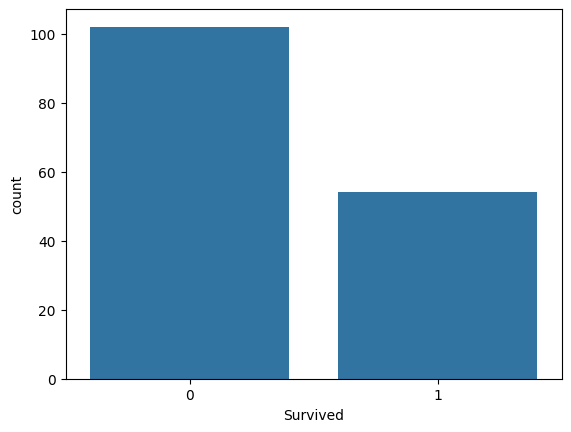

In [ ]:
sns.countplot(x="Survived", data=df)

# Q1
# Catégorie 0 (non survivant)

# Q2
# 100

# Q3
# 55

# Q4
# Ce n'est pas équilibré car il y a 50% de non survivant en plus

> **Questions :**
> 1. Quelle barre est la plus haute : la catégorie `0` (non survivants) ou
>    la catégorie `1` (survivants) ?
> 2. Environ combien de passagers semblent ne pas avoir survécu ?
> 3. Environ combien de passagers semblent avoir survécu ?
> 4. Que peut-on conclure sur l'équilibre du jeu de données pour cette
>    variable ? Le nombre de survivants est-il comparable à celui des
>    non-survivants ?

> **À FAIRE :**  
> Représenter la répartition des passagers selon leur sexe.  
> (Utiliser la même approche que précédement pour la variable indiquant la survie.)

<Axes: xlabel='Sex', ylabel='count'>

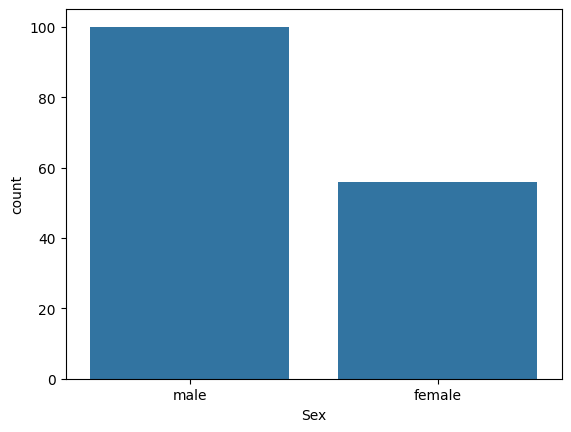

In [ ]:
sns.countplot(x="Sex", data=df)

# Q1
# male

# Q2
# Comme précédement, quasiment le double d'hommes par rapport au femmes

# Q3
# Nous pouvons déterminé si ce facteur est important dans la survie ou non

> **Questions :**
>
> 1. Quel sexe est le plus représenté dans le jeu de données ?
> 2. L'écart entre les deux catégories est-il important ?
> 3. En quoi cette information pourra-t-elle être utile lorsque l'on étudiera
>    la survie dans les étapes suivantes ?


> **À FAIRE :**  
> Exécuter la commande suivante qui utilise la fonction `catplot` pour afficher
> la répartition des survivants et des non survivants selon le sexe.


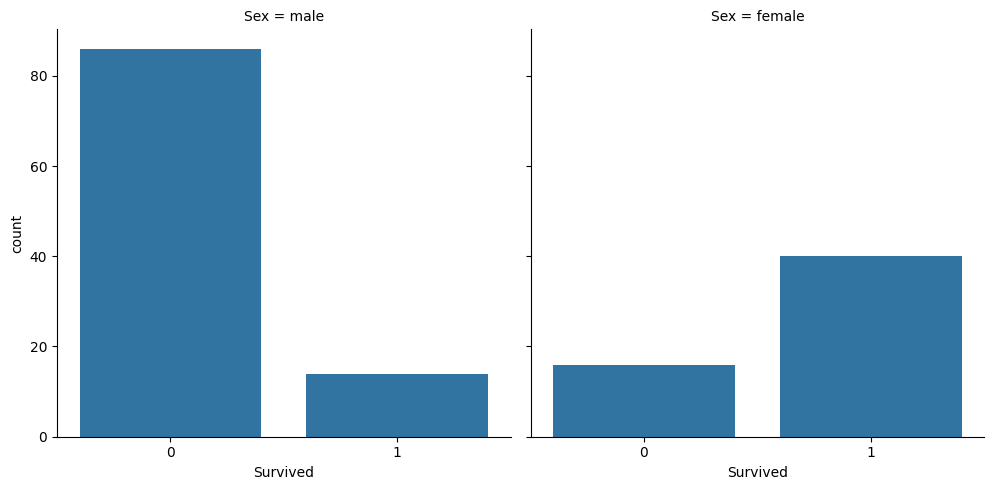

In [ ]:
sns.catplot(x="Survived", col="Sex", kind="count", data=df)

# Q1
# Les femmes

# Q2
# Les hommes

# Q3
# L'homme n'a que 20% de survie voir moins, la femme est a plus de 50%

# Q4
# En moyenne, être une femme augmente les chances de survie

La fonction `catplot` permet de représenter des données catégorielles en
créant automatiquement plusieurs graphiques côte à côte, ici un par valeur
de la variable `Sex`. Cela permet de comparer facilement deux distributions.

> **Questions :**
>
> 1. Pour quel sexe observe-t-on la proportion la plus élevée de survivants ?
> 2. Pour quel sexe la proportion de non survivants est-elle la plus importante ?
> 3. Quelle différence notable apparaît entre les deux distributions ?
> 4. En une phrase, que peut-on conclure concernant l'influence du sexe sur la
>    survie dans ce sous-ensemble du Titanic ?


> **À FAIRE :**  
> Exécuter la commande suivante pour visualiser la répartition des survivants
> et des non survivants selon la classe (`Pclass`) des passagers.


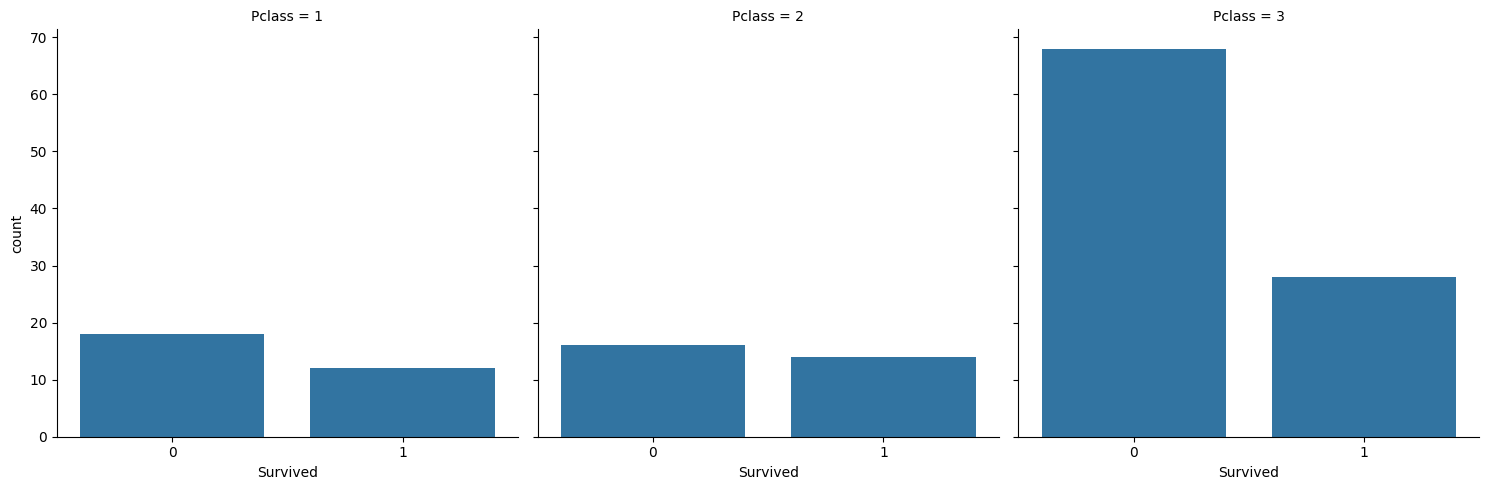

In [ ]:
sns.catplot(x="Survived", col="Pclass", kind="count", data=df)

# Q1
# La Pclass2

# Q2
# La Pclass 3

# Q3
# Entre la Pclass 1 et Pclass2 c'est quasiment identique mais la Pclass 3 est différente

# Q4
# En moyenne, être en Pclass 1 ou Pclass 2 augmente les chances de survie

La fonction `catplot` crée ici un graphique par catégorie de la variable `Pclass`.
Cela permet de comparer visuellement les taux de survie selon la classe du billet
(1re, 2e ou 3e classe).

> **Questions :**
>
> 1. Dans quelle classe observe-t-on la proportion la plus élevée de survivants ?
> 2. Quelle classe présente la proportion la plus élevée de non survivants ?
> 3. Les différences entre classes vous semblent-elles importantes ?
> 4. En une phrase, que peut-on conclure concernant l'influence de la classe
>    sur la survie ?


> **À FAIRE :**  
> Représenter la répartition des survivants et des non survivants selon le
> port d’embarquement (`Embarked`).  
> Vous pouvez vous inspirer du code utilisé précédemment pour `Sex` ou `Pclass`
> afin d'écrire la commande adaptée.


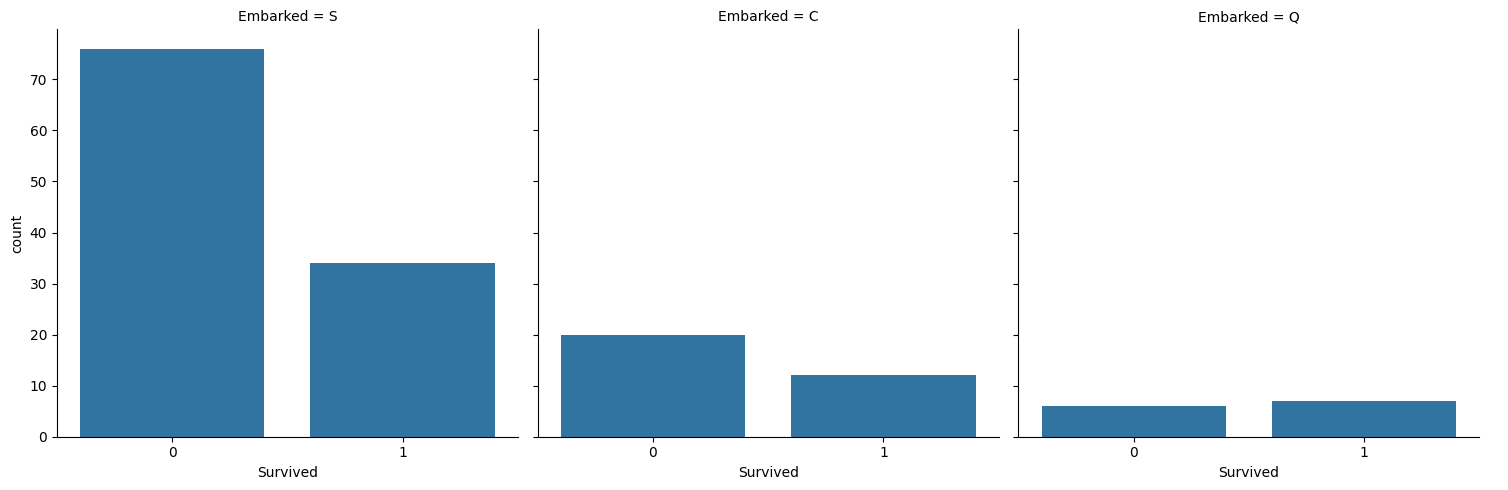

In [ ]:
# Nombre de survivant et de non survivant par embarquation (graphique)
sns.catplot(x="Survived", col="Embarked", kind="count", data=df)

# Q1
# S

# Q2
# S

# Q3
# Q

# Q4
# En moyenne, être sur l'embarquation C ou Q augmente les chances de survie

> **Questions :**
>
> 1. Quel port d'embarquement compte le plus de passagers dans ce jeu de données ?
> 2. Dans quel port observe-t-on la proportion la plus élevée de non survivants ?
> 3. Quel port présente la proportion la plus équilibrée entre survivants et
>    non survivants ?
> 4. Que peut-on en conclure concernant la variable `Embarked` et la survie ?


Le graphique précédent suggère que le port d'embarquement pourrait jouer un
rôle dans les différences observées entre survivants et non survivants. Il est
donc intéressant de vérifier si ce port est lui-même lié à la classe du billet.
Par exemple : les passagers de 1re classe, qui semblent mieux survivre, sont-ils
tous issus du même port ou non ?

> **À FAIRE :**  
> Représenter la répartition des classes (`Pclass`) en fonction du port
> d'embarquement (`Embarked`).  
> Vous pouvez vous inspirer des commandes précédentes pour écrire la bonne
> instruction.


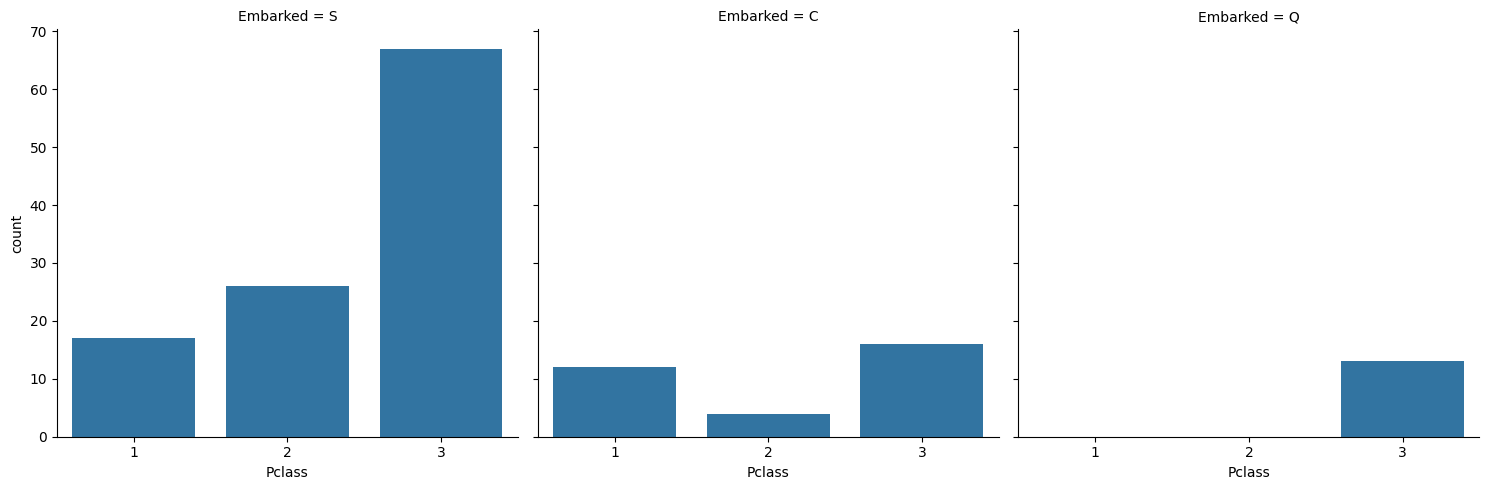

In [ ]:
# Nombre de passagers en fonction de la Pclass par embarquation (graphique)
sns.catplot(x="Pclass", col="Embarked", kind="count", data=df)

# Q1
# S

# Q2
# C

# Q3
# Oui, dans le port S il y a majoritairement des 3èmes classes, dans e port C l'équart est très faible (proportionnelement beaucoup plus de 1ère et 2ème classe) et le port Q ne contient que des classes 3

# Q4
# Les ports déterminent la classe du billet

> **Questions :**
>
> 1. Quel port embarque le plus de passagers de 3e classe ?
> 2. Quel port embarque proportionnellement le plus de passagers de 1re classe ?
> 3. Le port d'embarquement semble-t-il refléter une différence de classe sociale
>    dans ce sous-ensemble du Titanic ?
> 4. En une phrase, que pouvez-vous conclure sur le lien entre `Embarked` et
>    `Pclass` ?


Dans les graphiques précédents, nous avons observé séparément l’effet de la
classe (`Pclass`) et du sexe (`Sex`). Il peut être intéressant de combiner les
deux informations pour voir si certaines classes sont majoritairement
composées d'hommes ou de femmes, ce qui peut aussi influencer la survie.


> **À FAIRE :**  
> Représenter la répartition des passagers selon la classe (`Pclass`) en
> distinguant cette fois les hommes et les femmes grâce au paramètre `hue`.
> Vous pouvez vous inspirer des commandes précédentes.


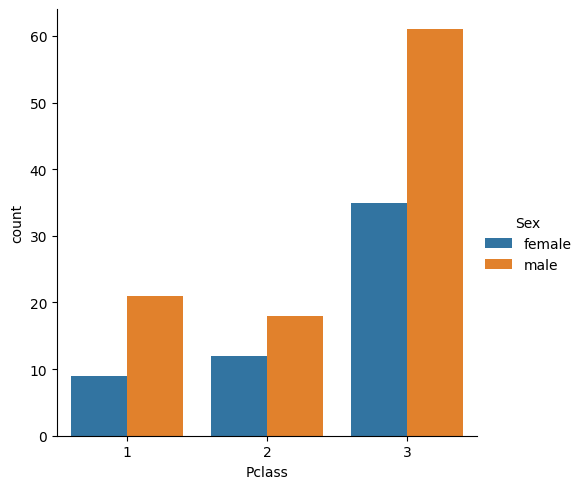

In [ ]:
# Nombre de passagers en fonction de la Pclass par embarquation (graphique)
sns.catplot(x="Pclass", hue="Sex", kind="count", data=df)

# Q1
# Classe 1

# Q2
# Classe 2

# Q3
# Elle est similaire dans la classe 1 et 3 et se rapporche dans la classe 2

# Q4
# Il y a proportionnelement plus d'homme dans la classe 1 et 3, comme on sait que les hommes ont plus de taux de décès il peut être intéréssent de regarder si les hommes ayant survécu sont plutot de la classe 1 ou 3

> **Questions :**
>
> 1. Dans quelle classe trouve-t-on la plus forte proportion d'hommes ?
> 2. Dans quelle classe trouve-t-on proportionnellement le plus de femmes ?
> 3. La répartition hommes/femmes est-elle similaire dans les trois classes ?
> 4. En quoi ces observations peuvent-elles aider à interpréter les résultats
>    de survie étudiés précédemment ?


Les visualisations précédentes complètent efficacement l'analyse réalisée avec
pandas : elles permettent de mieux comprendre la structure du jeu de données et
de repérer certains comportements possibles (survie selon le sexe, la classe ou
le port d'embarquement). Ces observations ne constituent pas des conclusions,
mais elles donnent des pistes d'interprétation. Lorsqu'on construira un modèle
de classification, ces hypothèses pourront être confirmées ou infirmées.

Même si l'on doit éviter d'introduire trop d'a priori, il reste utile de formuler des hypothèses sur les données pour orienter l'analyse. Pour aller plus loin, il est également important d'examiner des statistiques complémentaires : la forme des distributions, la présence éventuelle de valeurs extrêmes, ou encore les relations entre variables.


Nous commençons par la variable `Fare`, qui représente le prix du billet. Il
s'agit d'une variable numérique continue, et il est utile d'en visualiser la
distribution pour repérer sa forme générale (symétrique ou non), sa dispersion
et la présence éventuelle de valeurs extrêmes.


> **À FAIRE :**  
> Afficher la distribution de `Fare` à l'aide de `displot`.


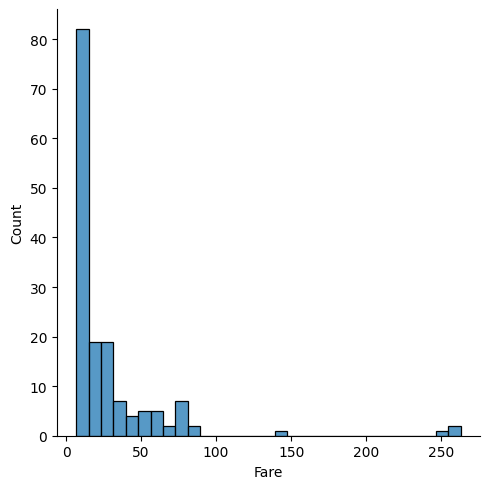

In [ ]:
sns.displot(df["Fare"])

# Q1
# Asymétrique

# Q2
# Prix faible (< 50€)

# Q4
# Les billets de classe 1

> **Questions :**
>
> 1. La distribution semble-t-elle symétrique ou asymétrique ?
> 2. La majorité des billets correspond-elle à des prix élevés ou faibles ?
> 3. Que représentent probablement les valeurs très élevées observées dans la
>    distribution ?


Nous examinons maintenant la distribution de l'âge des passagers. Il s'agit
d'une variable numérique continue. Visualiser sa distribution permet d'observer
les groupes d'âge les plus représentés, la dispersion et la présence éventuelle
de valeurs extrêmes.


> **À FAIRE :**  
> Exécuter la commande suivante pour afficher la distribution de `Age` à l'aide
> de la fonction `displot`.


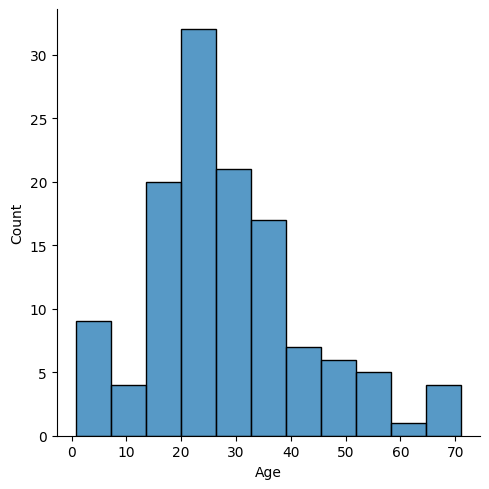

In [ ]:
sns.displot(df["Age"])

# Q1
# Entre 20 et 28 ans

# Q2
# Concentrer entre 15 et 40 ans

# Q3
# Non

> **Questions :**
>
> 1. Quels groupes d'âge semblent les plus représentés dans ce sous-échantillon ?
> 2. La distribution est-elle plutôt concentrée autour d'une zone, ou étalée ?
> 3. Observe-t-on des valeurs extrêmes (très jeunes ou très âgées) ?


Après avoir visualisé les distributions, il est utile d'examiner la dispersion
des variables numériques et la présence éventuelle de valeurs extrêmes. Les
diagrammes en boîte (`boxplot`) résument graphiquement la médiane, les
quartiles et les points atypiques.


> **À FAIRE :**  
> Afficher un `boxplot` pour `Fare`, puis un autre pour `Age`.


<Axes: xlabel='Fare'>

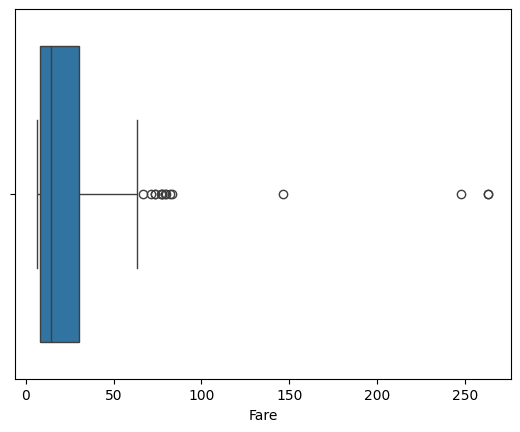

In [ ]:
sns.boxplot(x=df["Fare"])

# Q1
# Non, Fare est plus concentré sur ses petites valeurs (< 50)

# Q2
# Fare, avec beaucoup de billet très cher par rapport a la moyenne

# Q3
# Plus proche du bas de la boite, cela indique que les valeurs sont plus concentré vers le bas, et les valeurs extrèmes tirent la moyenne vers le haut, il y a donc un fort déséquilibre

> **Questions :**
>
> 1. Les deux variables (`Fare` et `Age`) montrent-elles une dispersion
>    similaire ?
> 2. Quel graphique révèle le plus de valeurs extrêmes ?
> 3. Pour `Fare`, la médiane est-elle proche du bas de la boîte ou centrée ?
>    Que cela indique-t-il ?


Les `violinplots` sont une autre manière de visualiser la distribution d'une
variable numérique. Ils combinent les informations d'un boxplot (médiane,
quartiles, dispersion, valeurs extrêmes) avec une estimation de densité, ce qui
permet d'observer la forme complète de la distribution.

Un violinplot est donc particulièrement utile pour :
- comparer la densité d'une variable (zones où les valeurs sont fréquentes),
- repérer des asymétries dans la distribution,
- visualiser la dispersion tout en conservant les repères du boxplot.

Nous allons les utiliser pour les variables `Fare` et `Age`.


> **À FAIRE :**  
> Afficher un `violinplot` pour `Fare`, puis un second pour `Age`.


<Axes: xlabel='Fare'>

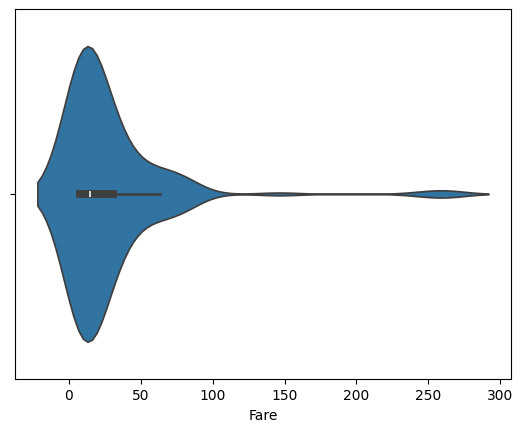

In [ ]:
sns.violinplot(x=df["Fare"])

<Axes: xlabel='Age'>

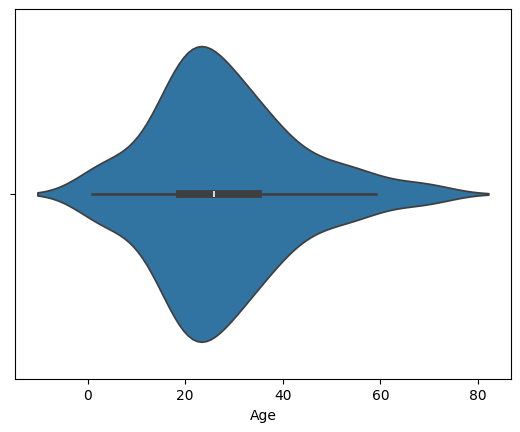

In [ ]:
sns.violinplot(x=df["Age"])

In [ ]:
# Q1
# Confirmation de la forte asymétrie à droite

# Q2
# Oui, entre 15 et 40 ans (comme observé précédemment)

# Q3
# L'age est bien plus symétrique que le prix du billet, l'age suit une loi normal mais le prix du billet est asymétrique

> **Questions :**
>
> 1. La forme du violinplot de `Fare` confirme-t-elle la forte asymétrie observée dans l'histogramme et le boxplot ?
> 2. Le violinplot de `Age` montre-t-il une zone principale de densité ?
>    La distribution semble-t-elle étalée ou concentrée ?
> 3. Les deux variables montrent-elles des comportements similaires ou très
>    différents ? Expliquer brièvement.


Jusqu'ici, nous avons surtout étudié chaque variable séparément. Avant de construire un modèle de classification, il est aussi utile de comprendre comment les variables numériques sont reliées entre elles.

L'analyse des corrélations permet par exemple de repérer des variables liées
(`Pclass` et `Fare`), des variables redondantes, ou au contraire des variables
faiblement corrélées qui apportent une information différente. Cela donne des
indications sur la structure des données et peut aider à préparer la modélisation.


> **À FAIRE :**  
> Exécuter le code suivant qui calcule  la matrice de corrélation des variables numériques du dataframe puis l'affiche sous forme de heatmap.


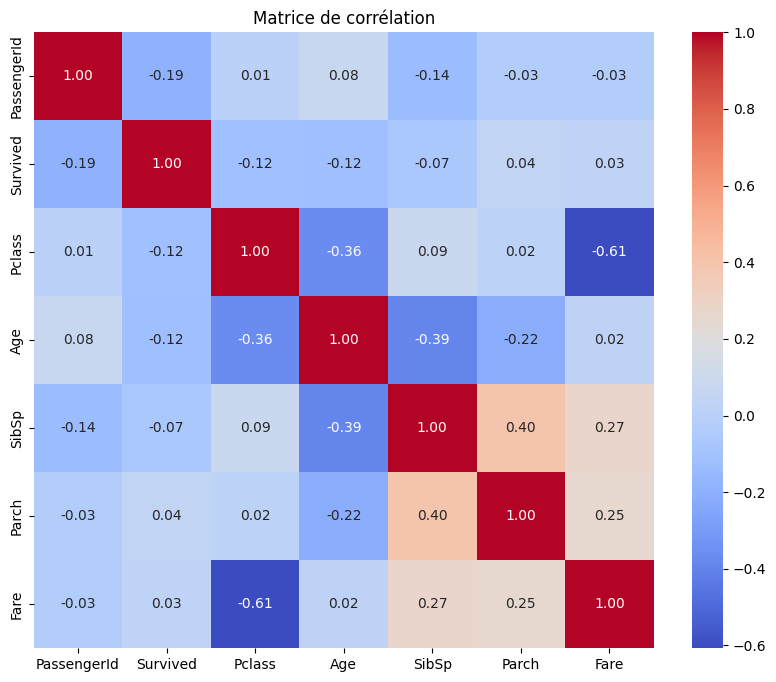

In [ ]:
# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=["float64", "int64"])

# Calcul de la matrice de corrélation
corr_matrix = num_cols.corr()

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
# Q1
# Pclass et Fare

# Q2
# Oui c'est normal, plus le prix augmente plus la classe diminue

# Q3
# Pas de corrélation

# Q4
# Nous pouvons vérifier si cette information de corrélation est prise en compte pendant l'entrainement, on peut également vérifié quand le classifieur se trompe s'il est trop biaisé par cette corrélation.
# Elle permettent également de détecter la redondance, identifier les variables inutiles et supprimer des biais trop important (passagerId corrélé avec survived)

> **Questions :**
>
> 1. Quelles paires de variables semblent les plus fortement corrélées
>    (en valeur absolue) ?
> 2. Le lien entre `Pclass` et `Fare` vous paraît-il logique au regard du
>    contexte du Titanic ?
> 3. Que signifie une corrélation proche de zéro entre deux variables ?
> 4. Pourquoi ces informations peuvent-elles être utiles avant d'entraîner
>    un modèle de classification ?

La visualisation nous a permis de compléter l'analyse réalisée avec pandas.
Certaines tendances repérées dans les statistiques descriptives deviennent
plus évidentes lorsqu'elles sont représentées graphiquement, comme la
répartition des survivants, les différences entre les classes ou encore
l'origine des passagers.

Les visualisations nous ont également permis d'identifier des valeurs extrêmes, en particulier pour l'attribut `Fare`, ce qui est un point essentiel avant de préparer les données pour un modèle d'apprentissage.

Ces premiers graphiques ne permettent pas encore de conclure, mais ils
donnent une lecture plus fine du jeu de données et aident à formuler des
hypothèses sur les facteurs qui pourraient influencer la survie. Dans la
suite du TP, nous allons passer aux étapes d'ingénierie des données afin de
préparer le jeu de données pour un futur modèle de classification.


# Ingénierie des données

Après avoir exploré et visualisé le jeu de données, l'étape suivante consiste à
préparer les données pour une utilisation dans un modèle de classification.
Cette phase, souvent appelée *ingénierie des données*, est essentielle : un
modèle ne pourra apprendre correctement que si les données sont complètes,
cohérentes et exprimées sous une forme exploitable.

Nous allons donc examiner plusieurs aspects pratiques : la gestion des valeurs
manquantes, la transformation et la création éventuelle d'attributs, le
traitement des variables catégorielles, ainsi que la sauvegarde du jeu de
données transformé. Ces opérations
conditionnent directement les performances du modèle final.


## Gestion des valeurs manquantes

Dans cette sous-section, nous allons identifier les valeurs manquantes et
réfléchir à la manière de les traiter. Elles peuvent concerner des attributs
numériques ou catégoriels et doivent être prises en compte avant toute
modélisation.


Avant de modifier le jeu de données, il est recommandé de travailler sur une
copie du dataframe afin de conserver intacte la version d'origine. Cette étape
permet de refaire des analyses ou de vérifier certains résultats sans risque
d'écraser les données initiales.


> **À FAIRE :**  
> Créer une copie du dataframe, `df2`, puis afficher le nombre de valeurs manquantes
> pour chaque colonne. (Pour tester si une valeur est manquante, il est possible pour un dataframe d'utiliser pour une colonne la fonction `isnull()`)


In [ ]:
df2 = df.copy()

df2.isnull().sum()

# Q1
# Age, Cabin et embarked

# Q2
# L'age est numérique, Cabin et emarked sont catégorielles

# Q3
# L'age est surement lié au taux de survie, pareil pour embarked, je ne pense pas que cabin soit important avec un aussi grand taux de cabin à null

# Q4
# Non elles nous font perdre trop d'information et peuvent induire des biais, surtout sur un petit jeu de données

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,30
SibSp,0
Parch,0
Ticket,0
Fare,0


> **Questions :**
>
> 1. Quelles colonnes contiennent des valeurs manquantes ?
> 2. Ces valeurs manquantes concernent-elles des variables numériques,
>    des variables catégorielles, ou les deux ?
> 3. Certaines colonnes vous semblent-elles particulièrement problématiques
>    pour la suite du TP ? Pourquoi ?
> 4. Est-il raisonnable de supprimer directement toutes les lignes contenant
>    des valeurs manquantes ? Dans quels cas cela pourrait poser problème ?

La variable `Age` comporte des valeurs manquantes. Comme il s'agit d'une
variable importante pour caractériser les passagers, il n'est pas souhaitable
de supprimer toutes les lignes concernées.   

Une stratégie simple consiste à remplacer les valeurs manquantes par une valeur représentative de la distribution, comme la médiane. Cette approche permet de conserver la taille du jeu de données tout en limitant l'impact des valeurs extrêmes.

> **À FAIRE :**  
> Remplacer les valeurs manquantes de la colonne `Age` par la médiane de la
> colonne. Mettre à jour `df2` en conséquence.


In [ ]:
# Remplacement des valeurs null de la colonne Age par la valeur médiane
df2['Age'] = df2['Age'].fillna(26)

# Q1
# Statistiquement, la médianne représente mieux la distribution

# Q2
# Elle modifiera la moyenne et la variance mais pas les quartiles

# Q3
# Forcément l'on va introduire des biais, vu que l'on va supposer un age qui n'est pas celui réel des passagers, le modèle va donc s'entrainer sur des passagers en ayant une "fausse" donnée sur eux

> **Questions :**
>
> 1. Pourquoi la médiane est-elle souvent préférée à la moyenne pour remplacer
>    des valeurs manquantes ?
> 2. Cette méthode modifie-t-elle la distribution de l'âge ? Dans quelle mesure ?
> 3. Quels pourraient être les inconvénients de cette approche ?


La colonne `Cabin` contient un très grand nombre de valeurs manquantes. Dans
ce cas, une imputation classique n'est pas pertinente, car l'information
manquante est majoritaire et la variable risque d'introduire du bruit plutôt
que d'apporter de l'information utile au modèle.

Une approche simple consiste
à regrouper toutes les valeurs manquantes dans une catégorie unique, ce qui
permet de conserver la colonne tout en limitant son impact. On peut par
exemple remplacer les valeurs manquantes par la valeur `'Unknown'`.


> **À FAIRE :**  
> Remplacer les valeurs manquantes de la colonne `Cabin` par la valeur
> `'Unknown'`. Mettre à jour `df2` en conséquence.


In [ ]:
# Remplacement des valeurs null de la colonne Cabin par la valeur 'Unknown'
df2['Cabin'] = df2['Cabin'].fillna('Unknown')

# Q1
# Car nous ne pouvons pas deviné le numéro de cabine (contrairement à l'âge)

# Q2
# Nous pouvons tout de même apprendre en fonction du peu de cabines que nous avons une corrélation entre variable

# Q3
# Oui car le modèle peut quand même corrélé le fait qu'une cabine soit inconnue avec la potentiel survie ou non du passager

> **Questions :**
>
> 1. Pourquoi l'imputation par une valeur unique est-elle adaptée dans le cas
>    de la colonne `Cabin` ?
> 2. Quels sont les avantages de conserver la colonne plutôt que de la
>    supprimer ?
> 3. Cette transformation peut-elle encore apporter de l'information à un
>    modèle de classification ?


La colonne `Embarked` indique le port d'embarquement des passagers. Elle ne
contient qu'une seule valeur manquante. Dans ce type de situation, il est
raisonnable de remplacer la valeur manquante par la modalité la plus
fréquente.

Cette stratégie permet de conserver la cohérence de la colonne
tout en évitant de supprimer une ligne entière pour un seul attribut manquant.

> **À FAIRE :**  
> Identifier la valeur la plus fréquente de la colonne `Embarked`, puis
> remplacer la valeur manquante par cette modalité dans `df2`.


In [ ]:
df2['Embarked'].describe()
# S est le plus fréquent avec 110 apparition sur 155

,Embarked
count,155
unique,3
top,S
freq,110


In [ ]:
# Remplacement des valeurs null de la colonne Embarked par la valeur la plus fréquente : S
df2['Embarked'] = df2['Embarked'].fillna('S')

# Q1
# Pour introduire le moins de biais possible

# Q2
# Oui car il introduirais trop de biais

# Q3
# La suppression de la ligne nous fait perdre plus d'information que "fausser" le remplissage

> **Questions :**
>
> 1. Pourquoi est-il raisonnable ici d'utiliser la modalité la plus fréquente
>    pour remplacer la valeur manquante ?
> 2. Cette stratégie pourrait-elle poser problème si le nombre de valeurs
>    manquantes était plus important ?
> 3. Pourquoi vaut-il mieux imputer la valeur plutôt que de supprimer la ligne ?


Cette étape nous a permis d'identifier les colonnes problématiques et de
choisir une stratégie adaptée pour chacune d'elles. Lorsque l'information
était partiellement manquante, comme pour `Age`, une imputation simple a
permis de conserver le jeu de données sans en réduire la taille. Dans le cas
d'une colonne très incomplète comme `Cabin`, regrouper les valeurs manquantes
dans une catégorie unique est une manière de conserver un signal potentiel
sans introduire d'hypothèse arbitraire. Enfin, pour une colonne presque
complète comme `Embarked`, remplacer la valeur manquante par la modalité la
plus fréquente est une solution raisonnable.

La gestion des valeurs manquantes est une étape incontournable : elle permet
de s'assurer que les données sont cohérentes, complètes et prêtes pour les
transformations suivantes. Dans la suite du TP, nous allons poursuivre
l'ingénierie des données en préparant les attributs pour un futur modèle de
classification.

## Encodage des variables catégorielles



Plusieurs colonnes du jeu de données sont de type catégoriel, comme `Sex`,
`Embarked` ou encore `Cabin`. Les modèles de classification ne peuvent pas
utiliser directement des chaînes de caractères et nécessitent une
représentation numérique. L'encodage consiste donc à transformer ces valeurs
catégorielles en valeurs numériques exploitables par un algorithme.

Dans cette sous-section, nous allons commencer par encoder la colonne `Sex`,
qui ne contient que deux modalités. Pour ce type de variable binaire, un
encodage simple à l'aide de `LabelEncoder` est suffisant.



> **À FAIRE :**  
> Utiliser `LabelEncoder` pour transformer la colonne `Sex` en valeurs
> numériques. Mettre à jour la colonne correspondante dans `df2`.


In [ ]:
le = LabelEncoder()

In [ ]:
df2['Sex'] = le.fit_transform(df2['Sex'])

In [ ]:
df2['Sex'].head()

# Q1
# Elle permet au modèle de prendre ces données en entrées car ils ne prennent que des valeurs numériques, ces calcules seront également plus rapide

# Q2
# Pas toujours, ici c'est parfait car cela est binaire

# Q3
# Introduction d'un biais ou le modèle peut interpréter une classe comme supérieur à une autre alors que ça n'a pas de rapport (exemple : les ports d'embarquations)

,Sex
0,1
1,0
2,0
3,0
4,1


> **Questions :**
>
> 1. Pourquoi l'encodage est-il nécessaire pour les variables catégorielles ?
> 2. L'encodage utilisé ici convient-il pour toutes les colonnes catégorielles
>    du jeu de données ?
> 3. Quelle serait la limite de cette méthode si une colonne possède plus
>    de deux modalités ?


La colonne `Embarked` contient plusieurs catégories correspondant aux ports
d'embarquement. Contrairement à la colonne `Sex`, cette variable possède plus
de deux modalités. Un encodage simple avec `LabelEncoder` ne serait pas
adapté, car il créerait un ordre artificiel entre les catégories.  
Pour ce type de variable, un encodage en plusieurs colonnes (one-hot encoding)
est plus approprié : chaque modalité est représentée par une colonne
indépendante valant 0 ou 1.

> **À FAIRE :**  
> Transformer la colonne `Embarked` en plusieurs colonnes indicatrices
> (one-hot encoding) et intégrer le résultat dans `df2`.


In [ ]:
df2 = pd.get_dummies(df2, columns=['Embarked'], prefix='Embarked', dtype=int)

In [ ]:
df2.head()

# Q1
# Il y a plus de deux catégories

# Q2
# On évite un ordre artificiel

# Q3
# Oui il l'augmente de n catégorie distinct

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,0,0,1


> **Questions :**
>
> 1. Pourquoi `LabelEncoder` n'est-il pas adapté pour une variable comme
>    `Embarked` ?
> 2. Quel est l'intérêt d'utiliser plusieurs colonnes (one-hot encoding) pour
>    représenter une variable catégorielle ?
> 3. Cet encodage peut-il augmenter la dimension du jeu de données ?


La colonne `Cabin` contient de nombreuses valeurs manquantes et des chaînes
de caractères relativement détaillées. Une manière simple de rendre cette
information exploitable sans augmenter excessivement la complexité du jeu de
données est d'extraire uniquement la première lettre de la cabine, qui
correspond en général au pont du navire. Cette simplification permet
d'obtenir une information catégorielle plus utile et plus stable, tout en
réduisant fortement le nombre de modalités.

Une fois cette première lettre extraite, l'encodage one-hot peut être appliqué
pour obtenir des colonnes indicatrices.


> **À FAIRE :**  
> Extraire la première lettre de la colonne `Cabin`, puis appliquer un
> one-hot encoding pour obtenir une représentation numérique exploitable.
> Mettre à jour `df2` en conséquence.


In [ ]:
df2['Cabin'] = df2['Cabin'].astype(str).str[0]

In [ ]:
df2 = pd.get_dummies(df2, columns=['Cabin'], prefix='Cabin', dtype=int)

In [ ]:
df2.head()

# Q1
# Le numéro précis de cabine n'est pas très important, seulement la première lettre donne une information sur la proximite entre la cabine et un des canneau de sauvetage le plus proche

# Q2
# Beaucoup trop de classe et d'augmentation de dimension, perte de corrélation entre les cabine proche

# Q3
# Oui il l'est car cette information est crucial

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_U
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,...,0,1,0,0,0,0,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,0,0,0,0,1,0,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,...,0,1,0,0,0,0,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,0,1,0,0,1,0,0,0,0,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,...,0,1,0,0,0,0,0,0,0,1


> **Questions :**
>
> 1. Pourquoi est-il intéressant de ne conserver que la première lettre de la
>    cabine ?
> 2. Quels seraient les inconvénients de conserver la chaîne complète de la
>    colonne `Cabin` ?
> 3. Le one-hot encoding est-il adapté ici, malgré le grand nombre de valeurs
>    manquantes initiales ?


## Traitement des variables continues



Certaines colonnes du jeu de données sont des variables continues, comme
`Age` ou `Fare`. Leur échelle peut varier fortement d'un attribut à l'autre
et cela peut influencer le comportement de nombreux modèles de classification.
Il est donc souvent utile de standardiser ou de normaliser ces variables afin
de les ramener sur une échelle comparable.

Dans cette sous-section, nous allons appliquer une transformation simple à
ces variables.


> **À FAIRE :**  
> Identifier les variables continues pertinentes dans `df2`, puis appliquer
> une transformation de type standardisation (soustraction de la moyenne et
> division par l'écart-type - cela se fait avec `StandardScaler() directement). Mettre à jour les colonnes correspondantes.


In [ ]:
ss = StandardScaler()

In [ ]:
df2['Age'] = ss.fit_transform(df2[['Age']])

In [ ]:
df2['Fare'] = ss.fit_transform(df2[['Fare']])

In [ ]:
df2['SibSp'] = ss.fit_transform(df2[['SibSp']])

In [ ]:
df2['Parch'] = ss.fit_transform(df2[['Parch']])

In [ ]:
df2.head()

# Q1
# Utile pour éviter les biais mathématique et tout mettre sur un pied d'égalité

# Q2
# Non certains sont résitant aux échelles (arbre de décision) mais d'autres pas du tout (SVM)

# Q3
# Perte de l'interprétation des vzleurs

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_U
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.437089,0.365311,-0.458217,A/5 21171,-0.531122,...,0,1,0,0,0,0,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.783472,0.365311,-0.458217,PC 17599,1.099279,...,0,0,0,0,1,0,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.131949,-0.584497,-0.458217,STON/O2. 3101282,-0.513935,...,0,1,0,0,0,0,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.554617,0.365311,-0.458217,113803,0.636300,...,0,1,0,0,1,0,0,0,0,0
4,5,0,3,"Allen, Mr. William Henry",1,0.554617,-0.584497,-0.458217,373450,-0.510753,...,0,1,0,0,0,0,0,0,0,1


> **Questions :**
>
> 1. Pourquoi est-il utile de standardiser les variables continues avant
>    d'entraîner un modèle ?
> 2. Tous les modèles nécessitent-ils une standardisation ? Pourquoi ?
> 3. En quoi cette transformation modifie-t-elle l'interprétation des valeurs
>    dans ces colonnes ?


In [ ]:
# Q1
# Car elle corresponde a une classe, donc binaire (0 ou 1)

# Q2
# Il est préférable de ne pas les normaliser mais d'utiliser le One-Hot Encoding, car la normalisation impose un écart mathématique constant entre les classes (1, 2, 3) alors que leur impact réel sur la survie n'est pas linéaire

# Q3
# Car c'est une classe binaire, pas besoin de normaliser

In [ ]:
# One hot sur Pclass
df2 = pd.get_dummies(df2, columns=['Pclass'], prefix='Pclass', dtype=int)

> **Questions :**
>
> 1. Pourquoi les colonnes issues d'un one-hot encoding ne doivent-elles pas
>    être normalisées ?
> 2. Les variables ordinales comme `Pclass` doivent-elles être normalisées ?
>    Quels arguments peut-on donner dans un sens ou dans l'autre ?
> 3. Pourquoi est-il préférable de ne pas normaliser la variable cible
>    `Survived` ?


## Suppression de certaines colonnes



Après le nettoyage et l’encodage, le dataframe contient encore des colonnes
qui ne seront pas utilisées directement par un futur modèle de classification.
Certaines colonnes servent uniquement d’identifiant (`PassengerId`), d’autres
sont textuelles et difficiles à exploiter telles quelles (`Name`, `Ticket`).

Pour simplifier le jeu de données et éviter d’introduire du bruit, nous allons
supprimer ces colonnes dans le dataframe préparé.


> **À FAIRE :**  
> Identifier les colonnes qui ne sont pas utiles pour l'apprentissage d'un
> modèle de classification dans ce TP (par exemple les identifiants ou les
> textes libres), puis les supprimer de `df2`.


In [ ]:
df2 = df2.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Q1
# Car elle ne donne aucune indication sur la survie ou non, l'id n'est pas exemple pas corrélé à la cabine

# Q2
# Elles peuvent être intéréssente mais pas dans notre contexte, lors d'une évacuation, le nom et le ticket ne servent a rien (à part si le ticket est relié à la cabine, mais ce n'est pas le cas ici)

# Q3
# On introduie moins de biais et le modèle sera plus rapide car il aura moins de données à traiter

> **Questions :**
>
> 1. Pourquoi la colonne `PassengerId` n'est-elle pas utile pour un modèle
>    de classification ?
> 2. Les colonnes `Name` et `Ticket` pourraient-elles contenir de
>    l'information intéressante ? Pourquoi choisit-on de ne pas les utiliser
>    dans ce TP ?
> 3. Quels sont les avantages de supprimer ces colonnes avant la modélisation ?


L'ensemble des étapes réalisées dans cette section a permis de transformer le
jeu de données initial en un format exploitable pour un futur modèle de
classification. Nous avons commencé par traiter les valeurs manquantes en
choisissant des stratégies adaptées à chaque colonne, puis nous avons encodé
les variables catégorielles afin d'obtenir des représentations numériques
compatibles avec les algorithmes d'apprentissage. Certaines colonnes ont été
simplifiées ou supprimées lorsqu'elles n'apportaient pas d'information utile
ou qu'elles risquaient d'introduire du bruit.

Le résultat est un dataframe plus structuré, plus cohérent et directement
utilisable dans une étape de modélisation. Toutes les variables sont désormais
numériques ou encodées sous forme de colonnes indicatrices, ce qui permet de
les intégrer dans la plupart des modèles de classification sans traitement
supplémentaire.

> **Remarque :** les colonnes issues du one-hot encoding peuvent apparaître sous forme booléenne. Cela ne pose pas de problème pour l'apprentissage notamment avec Scikit-Learn, mais il peut être plus simple, pour des raisons de cohérence ou de compatibilité avec certains outils, de convertir ces colonnes en valeurs entières (0 ou 1).

In [ ]:
# Conversion des colonnes booléennes en entiers (0/1)
bool_cols = df2.select_dtypes(include=['bool']).columns
df2[bool_cols] = df2[bool_cols].astype(int)

df2.dtypes

,0
Survived,int64
Sex,int64
Age,float64
SibSp,float64
Parch,float64
Fare,float64
Embarked_C,int64
Embarked_Q,int64
Embarked_S,int64
Cabin_A,int64


## Sauvegarde du fichier transformé

Le TP est maintenant terminé, il suffit de sauvegarder notre dataframe en `titanic_clean.csv` avec comme tabulateur des ';' en conservant l'entête.

In [ ]:
print ('Sauvegarde avec ; comme séparateur et avec entête \n')
df2.to_csv('titanic_clean.csv',sep=';', index=False)
print ("Fichier sauvegardé")


Sauvegarde avec ; comme séparateur et avec entête 

Fichier sauvegardé


Vérifier que votre fichier a été correctement sauvegardé.

In [ ]:
df=pd.read_csv('titanic_clean.csv', sep=';')
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_U,Pclass_1,Pclass_2,Pclass_3
0,0,1,-0.437089,0.365311,-0.458217,-0.531122,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0.783472,0.365311,-0.458217,1.099279,1,0,0,0,0,1,0,0,0,0,0,1,0,0
2,1,0,-0.131949,-0.584497,-0.458217,-0.513935,0,0,1,0,0,0,0,0,0,0,1,0,0,1
3,1,0,0.554617,0.365311,-0.458217,0.636300,0,0,1,0,0,1,0,0,0,0,0,1,0,0
4,0,1,0.554617,-0.584497,-0.458217,-0.510753,0,0,1,0,0,0,0,0,0,0,1,0,0,1


La prochaine fois nous utiliserons le jeu de données nettoyé pour faire de la classification.

# Alternative

In [12]:
le = LabelEncoder()
ss = StandardScaler()
df3 = df.copy()



df3['Age'] = df3['Age'].fillna(df3['Age'].median())

df3['Cabin'] = df3['Cabin'].fillna('Unknown')

df3['Sex'] = le.fit_transform(df3['Sex'])

df3 = pd.get_dummies(df3, columns=['Embarked', 'Pclass'], prefix='Embarked', dtype=int, drop_first=True)

df3['Age'] = ss.fit_transform(df3[['Age']])
df3['Fare'] = ss.fit_transform(df3[['Fare']])
df3['SibSp'] = ss.fit_transform(df3[['SibSp']])
df3['Parch'] = ss.fit_transform(df3[['Parch']])

df3['HasCabin'] = df3['Cabin'].apply(lambda x: 0 if x == 'Unknown' else 1)

df3['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df3['Title'] = df3['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df3['Title'] = df3['Title'].replace('Mlle', 'Miss')
df3['Title'] = df3['Title'].replace('Ms', 'Miss')
df3['Title'] = df3['Title'].replace('Mme', 'Mrs')

df3 = pd.get_dummies(df3, columns=['Title'], drop_first=True, dtype=int)

df3 = df3.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

bool_cols = df3.select_dtypes(include=['bool']).columns
df3[bool_cols] = df3[bool_cols].astype(int)



df3.to_csv('titanic_clean_2.csv', sep = ';', index = False)

<>:22: SyntaxWarning: invalid escape sequence '\.'
<>:22: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_311/1026905462.py:22: SyntaxWarning: invalid escape sequence '\.'
  df3['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
